# Notebook 12 — National-vs-DFW Wage-Index Sensitivity (ladder v1.1)

**Purpose.** The OPPS Medicare-FFS rung (NB11, Decision 33) is anchored on the **national unadjusted** rate for 73721 → APC 5523 = **\$243.77** (CY2026). NB11 Step S flagged that the *national-vs-DFW choice is load-bearing*: a DFW-wage-adjusted FFS rung can dip into the peer-MA cluster, weakening or inverting the "MA runs just below FFS" reading. This notebook isolates and formalizes that sensitivity.

**Two structural facts established (June 18) that shape this notebook:**

1. **"The DFW wage index" is not one number.** For Medicare, the metro splits into two wage-index areas — **Dallas–Plano–Irving (CBSA 19124)** and **Fort Worth–Arlington–Grapevine (CBSA 23104)** — and OPPS applies the IPPS post-reclassification wage index *per hospital*. A DFW-adjusted rung is therefore **not** a single benchmark line across the ladder.
2. **The crossover is itself a moving target.** The WI at which DFW-adjusted FFS equals the peer-MA cluster depends on the MA median, which is *still pending the Parkland fix* (≈\$233.88 now → ≈\$232.5 projected). So two pending inputs both bear on the same question.

**Design.** Self-contained in the NB10/NB11 mold (Step 0 → 1 → 2 → 3 → R → S → V → Findings → integrity). **No DB, no `queries.py`, no cross-notebook kernel dependency.** Wage-index *values* are PENDING sentinels (one edit drops them in once Table 3 is pulled); the sensitivity machinery and crossover analysis are fully computable now.

## Step 0 — Setup & prerequisite guard

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.axisbelow": True})

# This notebook is fully self-contained. The guard below makes an out-of-order
# run fail loudly with a clear message instead of a bare NameError downstream.
def require(*names):
    missing = [n for n in names if n not in globals()]
    if missing:
        raise RuntimeError(
            f"Prerequisite(s) not defined: {missing}. "
            f"Run the Step 1 reference-constants cell first (Restart & Run All)."
        )

print("Step 0 OK — DB-independent; no queries.py / NB9 / NB10 / NB11 kernel needed.")

Step 0 OK — DB-independent; no queries.py / NB9 / NB10 / NB11 kernel needed.


## Step 1 — Reference constants (static; no DB)

Two-flag discipline carried from NB11: `corroborated` = independent sources agree; `confirmed` = literal source file eyeballed.

In [2]:
# --- OPPS FFS reference (from NB11 / Decision 33) ---
NATIONAL_UNADJUSTED_RATE = 243.77   # 73721 -> APC 5523, CY2026 national unadjusted
RATE_FLAGS = {"corroborated": True, "confirmed": False}  # confirm vs literal Addendum B line

# OPPS payment splits into a labor-related portion (wage-index-adjusted) and a
# fixed non-labor portion. Using 0.60 reproduces NB11 Step S bounds exactly
# (see integrity self-test), so it is the value this project's ladder uses.
OPPS_LABOR_SHARE = 0.60             # confirm against CY2026 OPPS final rule
LABOR_SHARE_FLAGS = {"corroborated": True, "confirmed": False}

# --- Comparison anchors ---
MCA_COMMERCIAL = 906.53             # MCA commercial allowed, 73721
PEER_MA_MEDIAN_CURRENT   = 233.88   # peer-MA cluster median, pre-Parkland-fix
PEER_MA_MEDIAN_PROJECTED = 232.50   # projected post-Parkland-fix (verdict_parkland)

# --- The two DFW wage-index areas (values PENDING: CMS Table 3 by CBSA) ---
DFW_WAGE_AREAS = pd.DataFrame([
    {"area": "Dallas-Plano-Irving",        "cbsa": "19124", "wage_index": np.nan},
    {"area": "Fort Worth-Arlington-Grapevine", "cbsa": "23104", "wage_index": np.nan},
]).set_index("cbsa")
# To finalize: pull CMS Table 3, read off each CBSA, assign e.g.
#   DFW_WAGE_AREAS.loc["19124", "wage_index"] = <value>

# --- Hospital -> CBSA assignment (load-bearing: decides WHICH wage index applies) ---
# Parkland is Dallas County (confirmed). MCA is a WORKING ASSUMPTION — confirm the
# physical campus county before relying on it; a Fort Worth-side campus uses 23104.
HOSPITAL_CBSA = {
    "Parkland": "19124",   # Dallas County — confirmed
    "MCA":      "19124",   # WORKING ASSUMPTION — confirm campus county (else 23104)
}

print("Reference rate:", NATIONAL_UNADJUSTED_RATE, RATE_FLAGS)
print("Labor share:   ", OPPS_LABOR_SHARE, LABOR_SHARE_FLAGS)
print(DFW_WAGE_AREAS)

Reference rate: 243.77 {'corroborated': True, 'confirmed': False}
Labor share:    0.6 {'corroborated': True, 'confirmed': False}
                                 area  wage_index
cbsa                                             
19124             Dallas-Plano-Irving         NaN
23104  Fort Worth-Arlington-Grapevine         NaN


## Step 2 — OPPS wage-adjustment function

The single reusable transform. National unadjusted → wage-adjusted, splitting the
labor-related share and scaling only that portion by the area wage index:

$$\text{adj} = \text{national}\times\big(s_{labor}\cdot WI + (1-s_{labor})\big)$$

In [3]:
def opps_wage_adjust(national_rate, wage_index, labor_share=None):
    '''Wage-adjust an OPPS national unadjusted rate for a given area wage index.

    Only the labor-related share is scaled by WI; the remainder is fixed.
    Returns np.nan if wage_index is nan (PENDING), so downstream tables show
    PENDING rather than fabricating a point estimate.
    '''
    if labor_share is None:
        labor_share = OPPS_LABOR_SHARE
    return national_rate * (labor_share * wage_index + (1.0 - labor_share))

def crossover_wage_index(target_rate, national_rate=None, labor_share=None):
    '''WI at which the wage-adjusted FFS rate equals target_rate (e.g. the MA median).'''
    if national_rate is None: national_rate = NATIONAL_UNADJUSTED_RATE
    if labor_share is None:   labor_share   = OPPS_LABOR_SHARE
    return ((target_rate / national_rate) - (1.0 - labor_share)) / labor_share

# sanity: WI = 1.0 must return the national rate unchanged
assert np.isclose(opps_wage_adjust(NATIONAL_UNADJUSTED_RATE, 1.0), NATIONAL_UNADJUSTED_RATE)
print("Step 2 OK — opps_wage_adjust / crossover_wage_index defined.")

Step 2 OK — opps_wage_adjust / crossover_wage_index defined.


## Step 3 — Carried constants → the national multiple

In [4]:
require("MCA_COMMERCIAL", "NATIONAL_UNADJUSTED_RATE")
national_multiple = MCA_COMMERCIAL / NATIONAL_UNADJUSTED_RATE
print(f"MCA commercial            : ${MCA_COMMERCIAL:,.2f}")
print(f"FFS national (unadjusted) : ${NATIONAL_UNADJUSTED_RATE:,.2f}")
print(f"Commercial / FFS multiple : {national_multiple:.3f}x   (NB11 headline ~3.72x)")

MCA commercial            : $906.53
FFS national (unadjusted) : $243.77
Commercial / FFS multiple : 3.719x   (NB11 headline ~3.72x)


## Step R — Reconciliation: per-scenario FFS rung & multiple

National is the single, hospital-agnostic benchmark line. The two DFW divisions are
per-hospital and remain **PENDING** until Table 3 is pulled — shown here so the table
structure is ready for a one-line drop-in.

In [5]:
require("DFW_WAGE_AREAS", "OPPS_LABOR_SHARE", "MCA_COMMERCIAL",
        "PEER_MA_MEDIAN_CURRENT", "PEER_MA_MEDIAN_PROJECTED")

rows = []
# National (the headline benchmark line — WI not applicable)
rows.append({
    "scenario": "National (unadjusted)", "cbsa": "—", "wage_index": np.nan,
    "ffs_rung": NATIONAL_UNADJUSTED_RATE,
    "mult_vs_commercial": MCA_COMMERCIAL / NATIONAL_UNADJUSTED_RATE,
    "ffs_minus_MA_current":   NATIONAL_UNADJUSTED_RATE - PEER_MA_MEDIAN_CURRENT,
    "ffs_minus_MA_projected": NATIONAL_UNADJUSTED_RATE - PEER_MA_MEDIAN_PROJECTED,
})
# The two DFW divisions
for cbsa, r in DFW_WAGE_AREAS.iterrows():
    wi = r["wage_index"]
    rung = opps_wage_adjust(NATIONAL_UNADJUSTED_RATE, wi)
    rows.append({
        "scenario": r["area"], "cbsa": cbsa, "wage_index": wi,
        "ffs_rung": rung,
        "mult_vs_commercial": (MCA_COMMERCIAL / rung) if pd.notna(rung) else np.nan,
        "ffs_minus_MA_current":   (rung - PEER_MA_MEDIAN_CURRENT) if pd.notna(rung) else np.nan,
        "ffs_minus_MA_projected": (rung - PEER_MA_MEDIAN_PROJECTED) if pd.notna(rung) else np.nan,
    })

recon = pd.DataFrame(rows).set_index("scenario")
print("Peer-MA median (current / projected): "
      f"${PEER_MA_MEDIAN_CURRENT:,.2f} / ${PEER_MA_MEDIAN_PROJECTED:,.2f}\n")
print("NaN rows = PENDING Table 3 wage index. Positive ffs_minus_MA => FFS above MA.")
recon

Peer-MA median (current / projected): $233.88 / $232.50

NaN rows = PENDING Table 3 wage index. Positive ffs_minus_MA => FFS above MA.


,cbsa,wage_index,ffs_rung,mult_vs_commercial,ffs_minus_MA_current,ffs_minus_MA_projected
scenario,,,,,,
National (unadjusted),—,NaN,243.7700,3.7188,9.8900,11.2700
Dallas-Plano-Irving,19124,NaN,NaN,NaN,NaN,NaN
Fort Worth-Arlington-Grapevine,23104,NaN,NaN,NaN,NaN,NaN


## Step S — Sensitivity sweep + crossover

Sweep WI 0.90–1.10 (NB11 range). The crossover WI — where DFW-adjusted FFS meets the
MA cluster — is computed for **both** MA medians, because the Parkland fix moves it.

In [6]:
require("opps_wage_adjust", "crossover_wage_index")
wi_grid = np.round(np.arange(0.90, 1.1001, 0.01), 2)
sweep = pd.DataFrame({"wage_index": wi_grid})
sweep["ffs_rung"]   = opps_wage_adjust(NATIONAL_UNADJUSTED_RATE, sweep["wage_index"])
sweep["multiple"]   = MCA_COMMERCIAL / sweep["ffs_rung"]
sweep["vs_MA_curr"] = sweep["ffs_rung"] - PEER_MA_MEDIAN_CURRENT
sweep["vs_MA_proj"] = sweep["ffs_rung"] - PEER_MA_MEDIAN_PROJECTED

xo_curr = crossover_wage_index(PEER_MA_MEDIAN_CURRENT)
xo_proj = crossover_wage_index(PEER_MA_MEDIAN_PROJECTED)

print(f"Multiple over WI[0.90,1.10] : [{sweep['multiple'].min():.3f}x, "
      f"{sweep['multiple'].max():.3f}x]   (NB11 Step S: [3.51x, 3.96x])\n")
print(f"Crossover WI (current  MA ${PEER_MA_MEDIAN_CURRENT:.2f}) : {xo_curr:.4f}")
print(f"Crossover WI (projected MA ${PEER_MA_MEDIAN_PROJECTED:.2f}) : {xo_proj:.4f}")
print("\n  - Above the crossover: DFW-adjusted FFS >= MA  -> 'MA below FFS' holds, multiple compresses.")
print("  - Below the crossover: DFW-adjusted FFS dips into the MA cluster -> reading weakens / inverts.")
print(f"\nThe Parkland fix slides the crossover by {abs(xo_curr - xo_proj):.4f} WI units "
      f"({xo_curr:.3f} -> {xo_proj:.3f}).")
sweep.head()

Multiple over WI[0.90,1.10] : [3.508x, 3.956x]   (NB11 Step S: [3.51x, 3.96x])

Crossover WI (current  MA $233.88) : 0.9324
Crossover WI (projected MA $232.50) : 0.9229

  - Above the crossover: DFW-adjusted FFS >= MA  -> 'MA below FFS' holds, multiple compresses.
  - Below the crossover: DFW-adjusted FFS dips into the MA cluster -> reading weakens / inverts.

The Parkland fix slides the crossover by 0.0094 WI units (0.932 -> 0.923).


,wage_index,ffs_rung,multiple,vs_MA_curr,vs_MA_proj
0,0.9000,229.1438,3.9562,-4.7362,-3.3562
1,0.9100,230.6064,3.9311,-3.2736,-1.8936
2,0.9200,232.0690,3.9063,-1.8110,-0.4310
3,0.9300,233.5317,3.8818,-0.3483,1.0317
4,0.9400,234.9943,3.8577,1.1143,2.4943


## Step V — Visualization

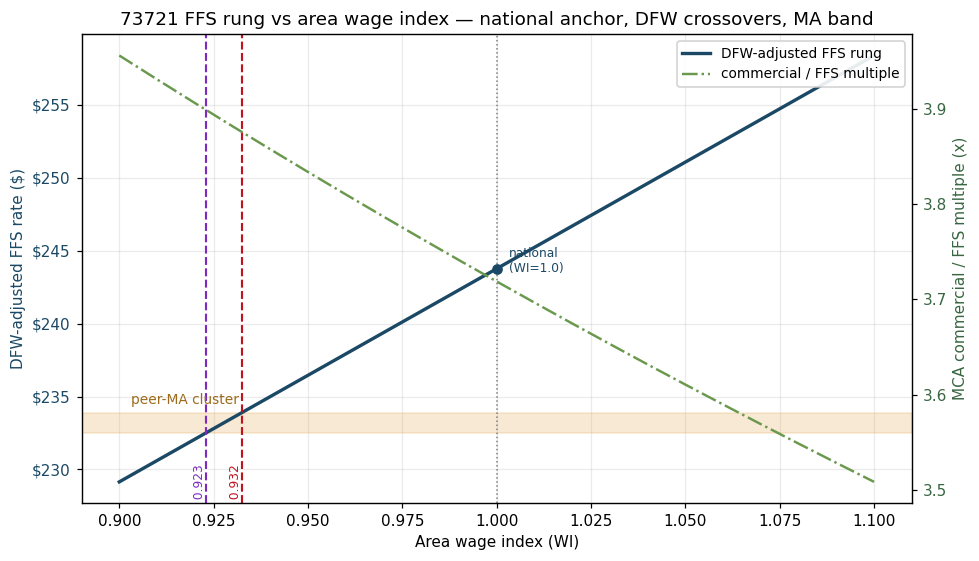

In [7]:
require("sweep", "xo_curr", "xo_proj")
fig, axL = plt.subplots(figsize=(9, 5.2))

# Left axis: DFW-adjusted FFS rung
axL.plot(sweep["wage_index"], sweep["ffs_rung"], color="#1b4965", lw=2.2,
         label="DFW-adjusted FFS rung")
axL.set_xlabel("Area wage index (WI)")
axL.set_ylabel("DFW-adjusted FFS rate ($)", color="#1b4965")
axL.tick_params(axis="y", labelcolor="#1b4965")
axL.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}"))

# MA cluster band (current..projected medians)
lo, hi = sorted([PEER_MA_MEDIAN_PROJECTED, PEER_MA_MEDIAN_CURRENT])
axL.axhspan(lo, hi, color="#e09f3e", alpha=0.22)
axL.text(0.903, hi + 0.4, "peer-MA cluster", color="#9c6b1a", fontsize=9, va="bottom")

# National reference point (WI = 1.0 -> national unadjusted)
axL.axvline(1.0, color="grey", ls=":", lw=1)
axL.scatter([1.0], [NATIONAL_UNADJUSTED_RATE], color="#1b4965", zorder=5)
axL.annotate("national\n(WI=1.0)", (1.0, NATIONAL_UNADJUSTED_RATE),
             textcoords="offset points", xytext=(8, -2), fontsize=8, color="#1b4965")

# Crossovers
for xo, lab, c in [(xo_curr, f"crossover (MA curr) {xo_curr:.3f}", "#c1121f"),
                   (xo_proj, f"crossover (MA proj) {xo_proj:.3f}", "#7b2cbf")]:
    axL.axvline(xo, color=c, ls="--", lw=1.4)
    axL.text(xo, axL.get_ylim()[0], f" {xo:.3f}", color=c, fontsize=8,
             rotation=90, va="bottom", ha="right")

# Right axis: commercial / FFS multiple
axR = axL.twinx()
axR.plot(sweep["wage_index"], sweep["multiple"], color="#6a994e", lw=1.6, ls="-.",
         label="commercial / FFS multiple")
axR.set_ylabel("MCA commercial / FFS multiple (x)", color="#386641")
axR.tick_params(axis="y", labelcolor="#386641")
axR.grid(False)

lines = axL.get_lines()[:1] + axR.get_lines()[:1]
axL.legend(lines, [l.get_label() for l in lines], loc="upper right", fontsize=9, framealpha=0.9)
axL.set_title("73721 FFS rung vs area wage index — national anchor, DFW crossovers, MA band")
plt.tight_layout()
plt.show()

## Findings

- **National stays the headline; DFW-adjusted is a per-hospital sensitivity.** Only the national unadjusted rate (\$243.77) is a single constant per code per year — one benchmark line across the whole ladder. A DFW-adjusted rung splits into the two CBSAs (19124 / 23104) and varies per hospital, so it can't *be* the headline line without breaking the "one line" property of Decision 33. Recommended framing: **headline = national; DFW-adjusted = labeled sensitivity.**

- **The finding's direction hinges on two still-pending inputs, not one.** Whether "MA runs just below FFS / multiple compresses" survives DFW-adjustment depends on (a) the actual wage index for the relevant CBSA and (b) the MA median, which is itself pending `verdict_parkland`. Both push the crossover around. With current MA (~\$233.88) the crossover sits near **WI ≈ 0.932**; with the projected post-fix MA (~\$232.50) it drops to **WI ≈ 0.923**. So the Parkland fix and the Table-3 pull are *jointly* load-bearing.

- **The multiple is robust in magnitude even where direction isn't.** Across WI[0.90, 1.10] the commercial/FFS multiple stays in **[3.51×, 3.96×]** — it never collapses. The fragility is in the qualitative "MA vs FFS" ordering near the crossover, not in the headline "~3.7× Medicare" claim.

- **`MCA`'s CBSA assignment is load-bearing and unconfirmed.** If MCA's campus is Dallas-side (19124) it shares Parkland's wage index; a Fort Worth-side campus (23104) takes the other value and a *different* crossover position. Confirm before drawing per-hospital conclusions.

## Integrity self-test

In [ ]:
# 1. Identity: WI = 1.0 returns national unchanged
assert np.isclose(opps_wage_adjust(NATIONAL_UNADJUSTED_RATE, 1.0), NATIONAL_UNADJUSTED_RATE)

# 2. Monotone increasing in WI
_r = opps_wage_adjust(NATIONAL_UNADJUSTED_RATE, wi_grid)
assert np.all(np.diff(_r) > 0)

# 3. Reproduces NB11 Step S multiple bounds at the WI endpoints
assert np.isclose(MCA_COMMERCIAL / opps_wage_adjust(NATIONAL_UNADJUSTED_RATE, 0.90), 3.956, atol=0.01)
assert np.isclose(MCA_COMMERCIAL / opps_wage_adjust(NATIONAL_UNADJUSTED_RATE, 1.10), 3.508, atol=0.01)

# 4. Crossovers recover NB11's ~0.923 (projected) and the current-MA ~0.932
assert np.isclose(crossover_wage_index(PEER_MA_MEDIAN_PROJECTED), 0.9229, atol=0.001)
assert np.isclose(crossover_wage_index(PEER_MA_MEDIAN_CURRENT),   0.9324, atol=0.001)

# 5. National multiple ~3.72x
assert np.isclose(MCA_COMMERCIAL / NATIONAL_UNADJUSTED_RATE, 3.719, atol=0.005)

# 6. Labor share is a valid proportion
assert 0.0 < OPPS_LABOR_SHARE < 1.0

# 7. PENDING wage indices propagate as NaN (no fabricated point estimates)
assert recon.loc[["Dallas-Plano-Irving", "Fort Worth-Arlington-Grapevine"], "ffs_rung"].isna().all()

print("ALL INTEGRITY CHECKS PASSED")